Style setup complete. C_SQL, C_SL_V1, C_SL_V2, DPI_SAVE, and
finalize_and_save() are now available to every section below.


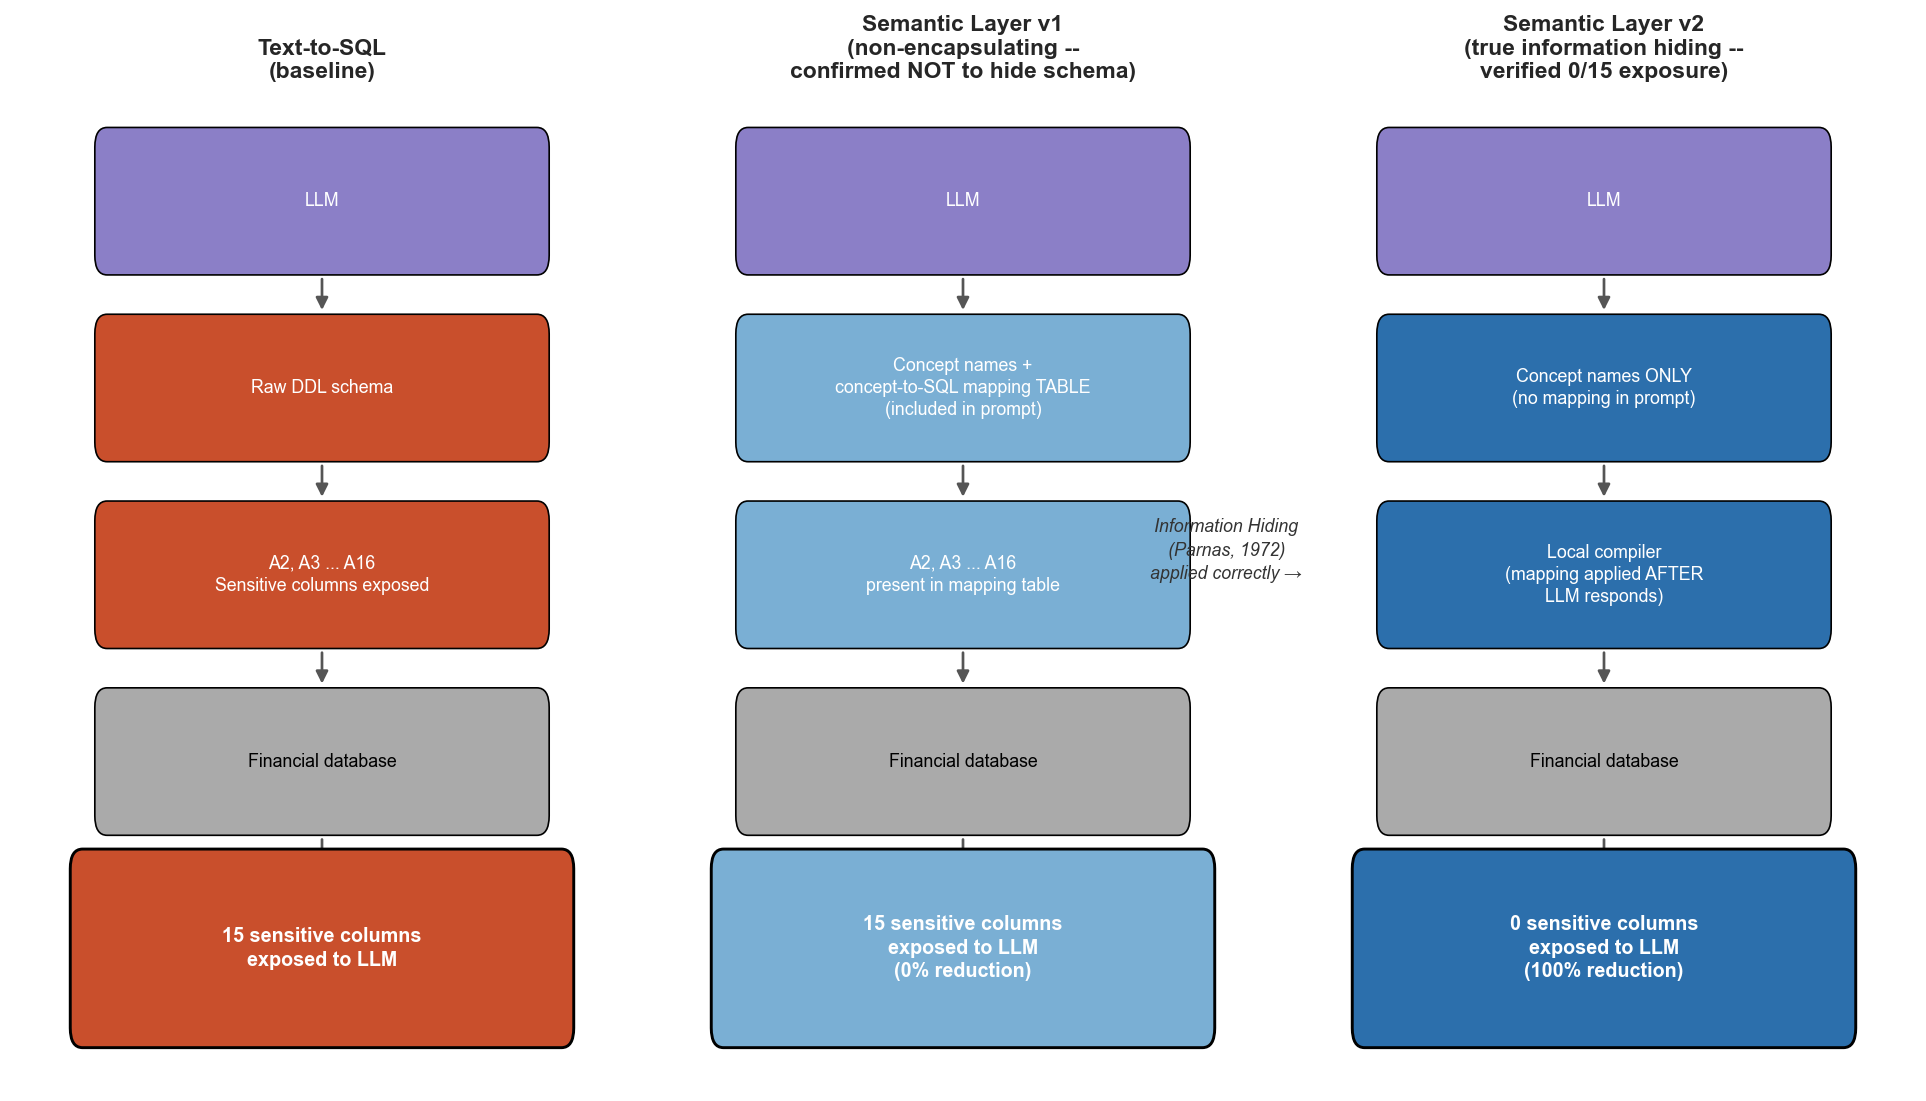

Saved: fig01_architecture_comparison.png  (695 KB, 600 DPI)
Figure 3: computed Phase 3 v1=38.7%, v2=38.7%, paired p=1 (n=60 question pairs)


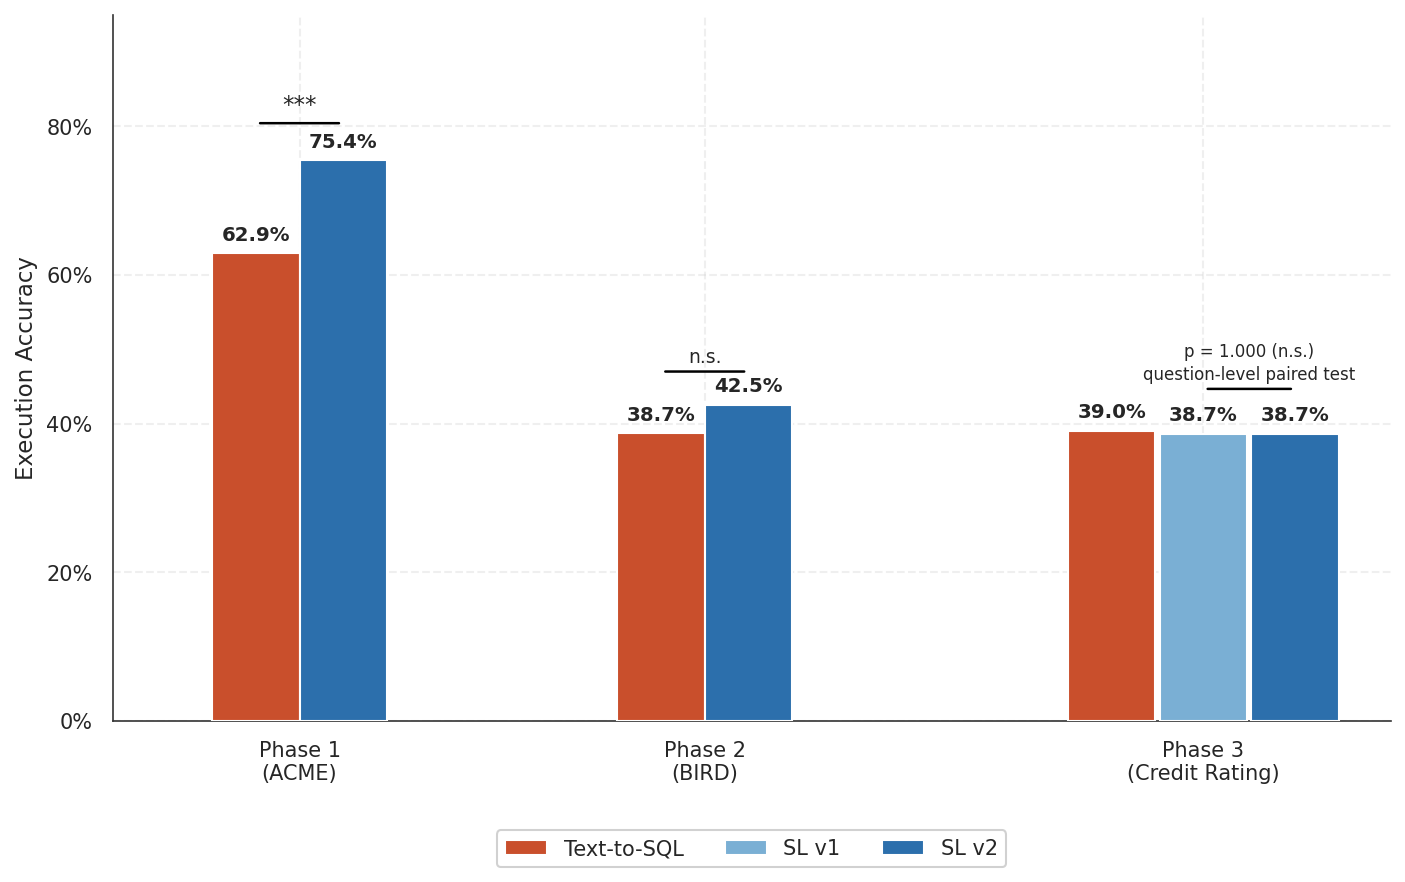

Saved: fig03_overall_accuracy.png  (292 KB, 600 DPI)
Figure 4: computed Phase 3 v1=['66.4%', '38.6%', '2.9%'], v2=['60.9%', '41.9%', '5.9%']


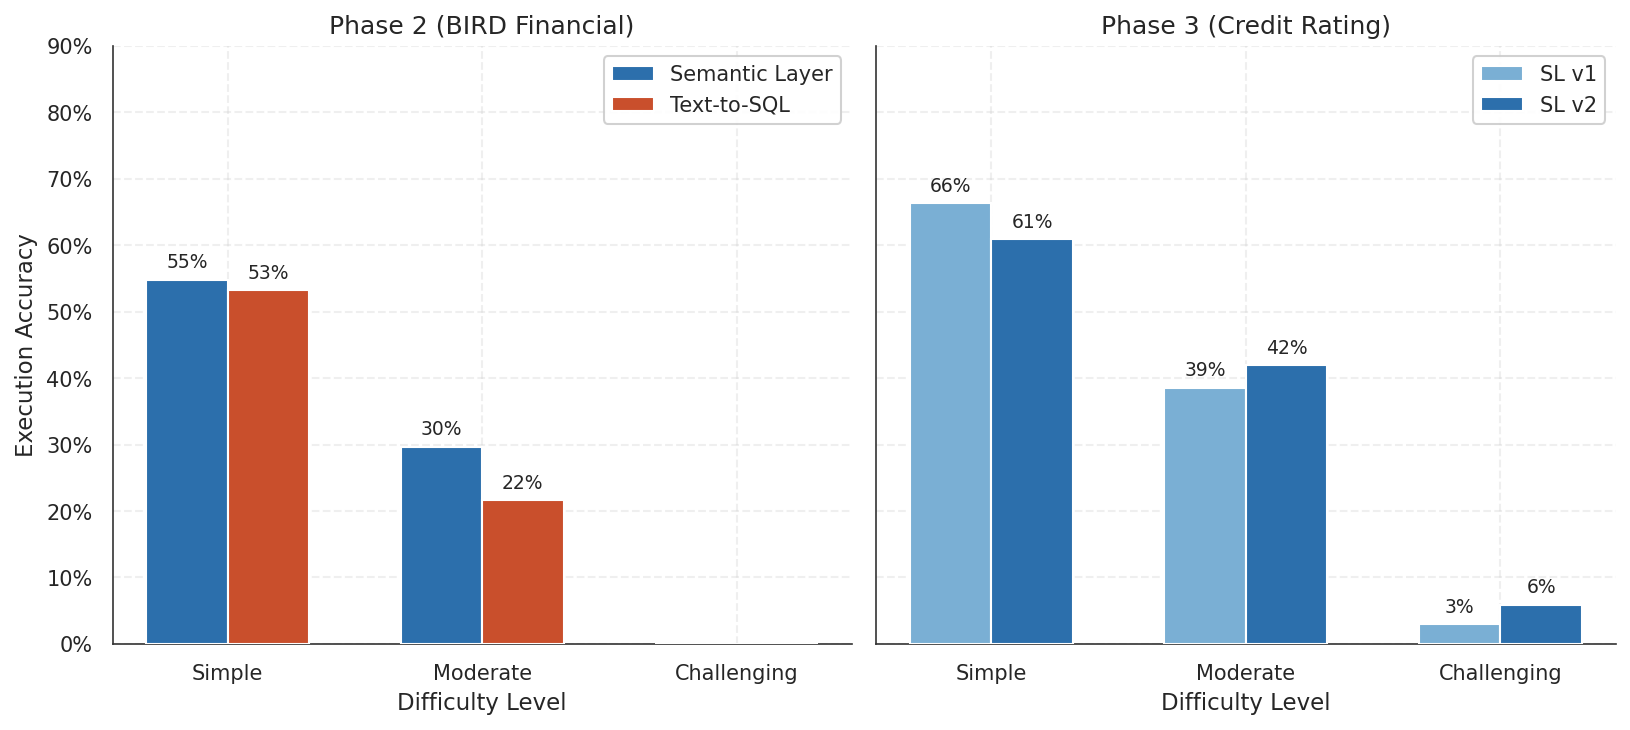

Saved: fig04_difficulty_accuracy.png  (375 KB, 600 DPI)
Verification: 12 bar patches drawn (expected 12).
✓ OK


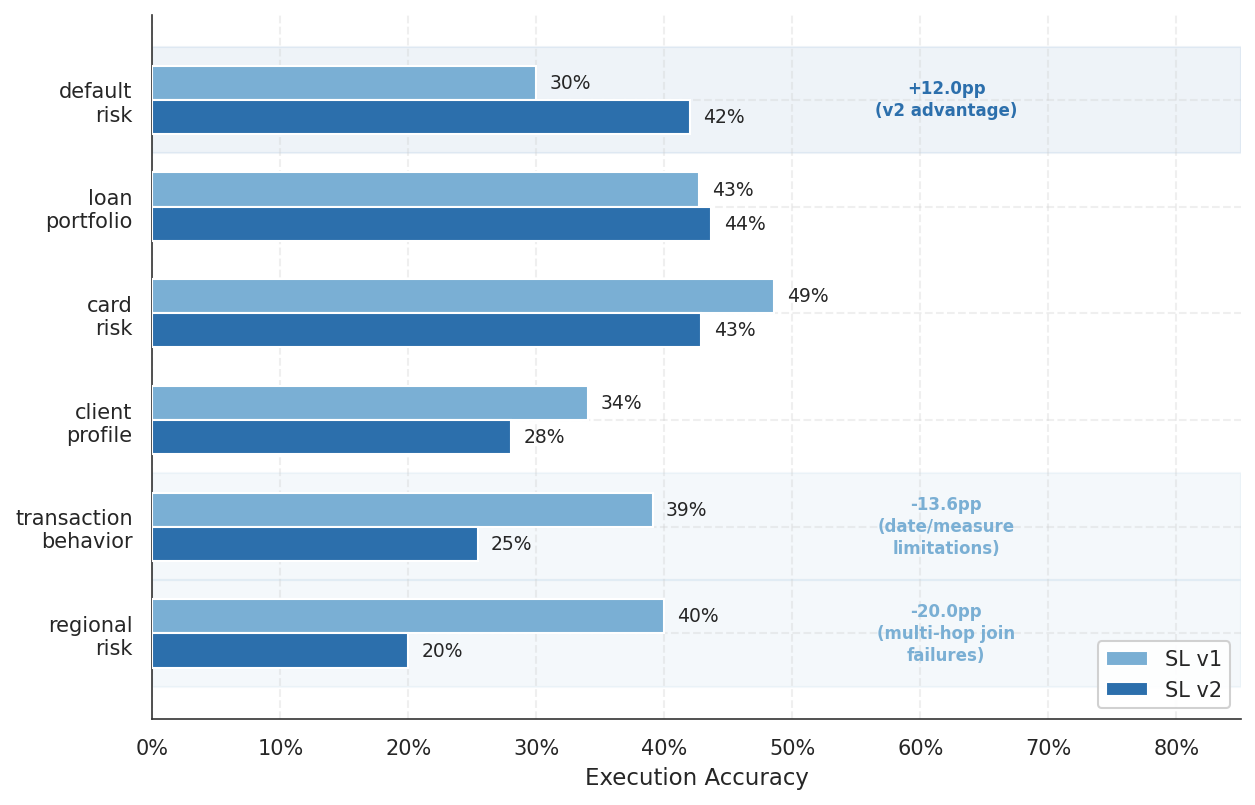

Saved: fig05_category_accuracy.png  (354 KB, 600 DPI)


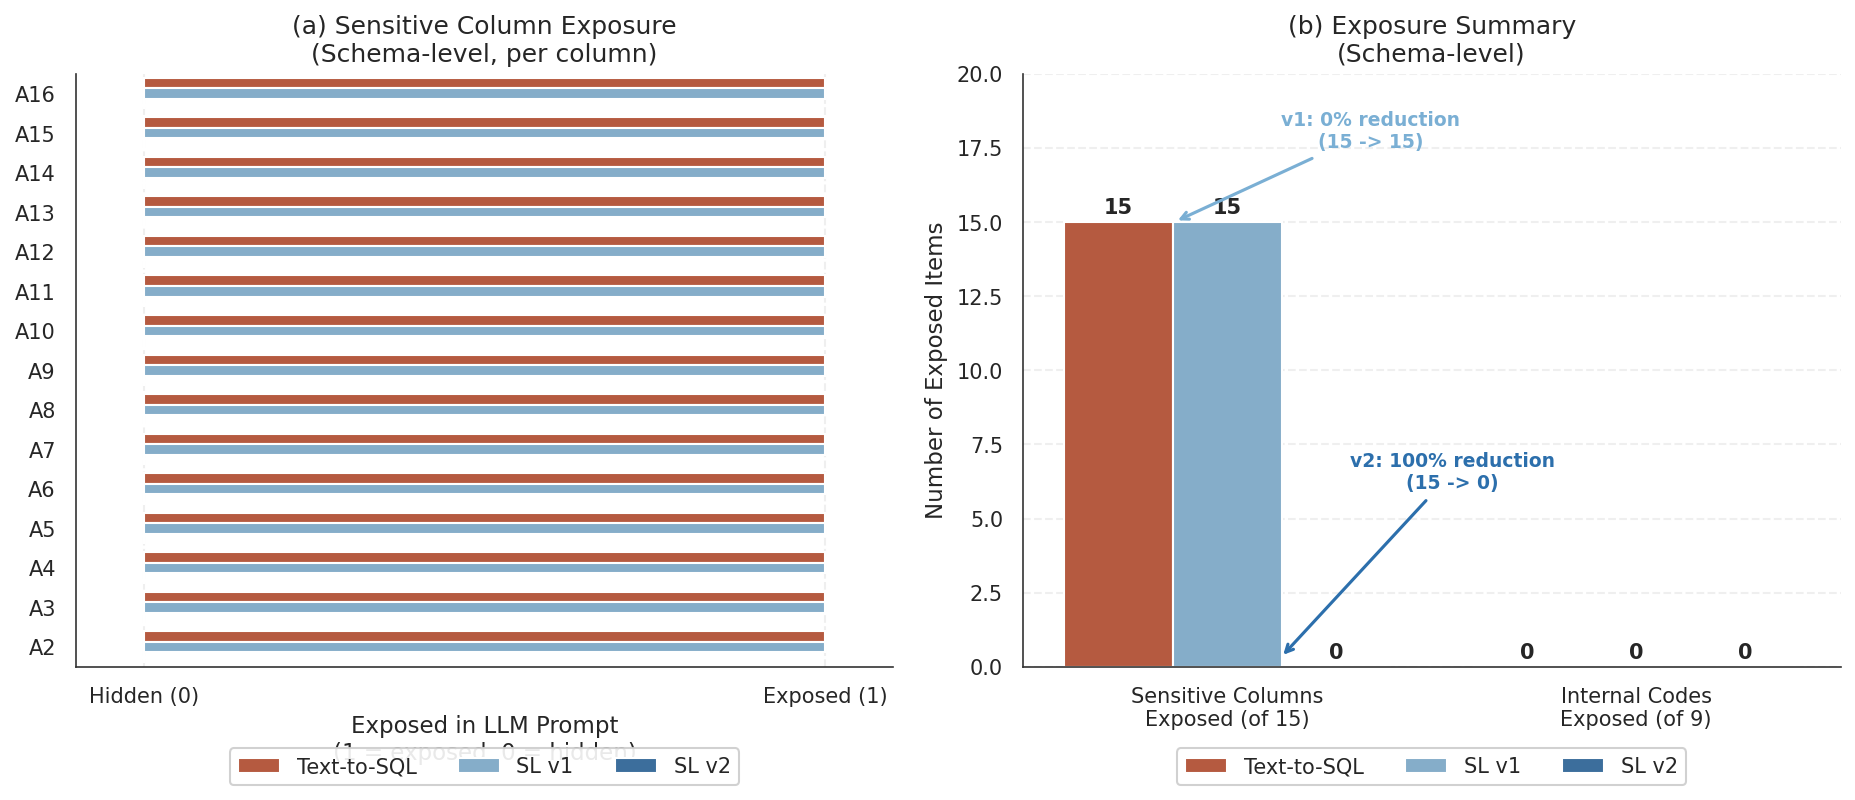

Saved: fig06_exposure_comparison.png  (509 KB, 600 DPI)
Loaded actual per-iteration data from results files.
v1 per-iteration: [0.4        0.38333333 0.375      0.4        0.375     ]
v2 per-iteration: [0.36666667 0.4        0.36666667 0.4        0.4       ]


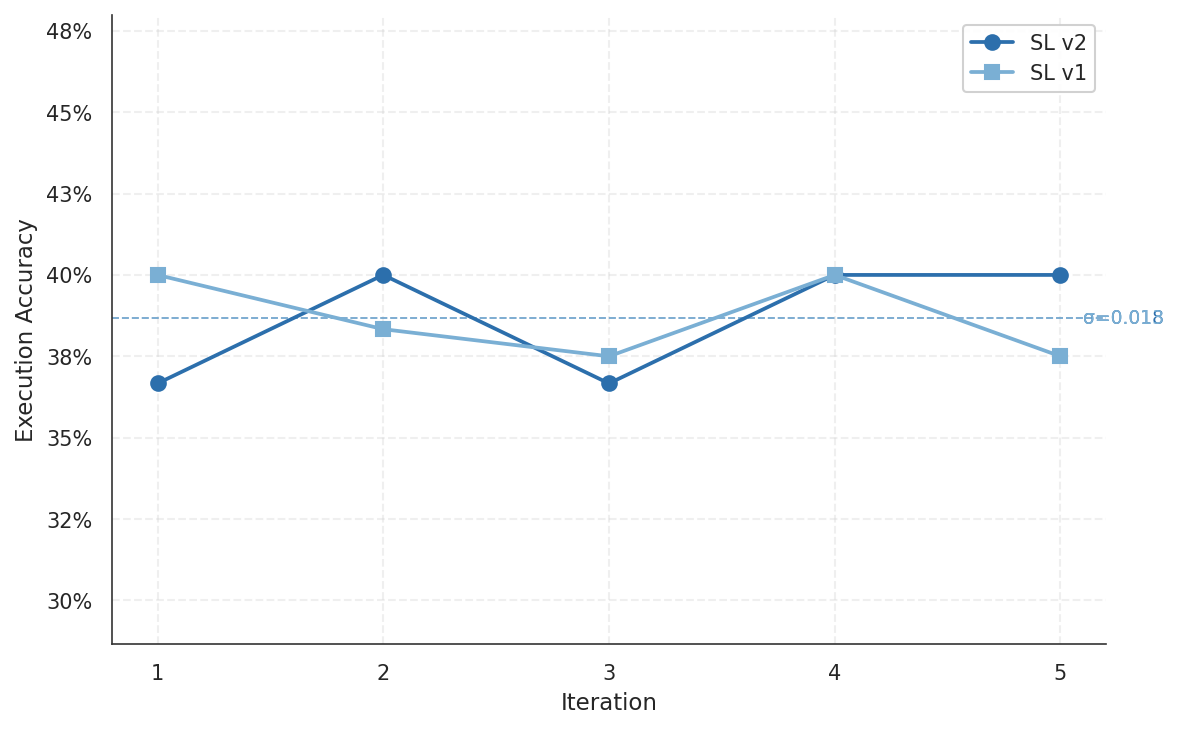

Saved: fig07_iteration_stability.png  (280 KB, 600 DPI)

v2 mean across iterations: 0.3867 (should match overall v2 accuracy 0.330 closely)
v1 mean across iterations: 0.3867 (should match overall v1 accuracy 0.387 closely)
Loaded category-level data for both models:
               category  GPT-4o-mini    GPT-4o      diff
0             card_risk     0.657143  0.542857 -0.114286
1        client_profile     0.320000  0.260000 -0.060000
2        loan_portfolio     0.454545  0.454545  0.000000
3          default_risk     0.440000  0.500000  0.060000
4  transaction_behavior     0.272727  0.345455  0.072727
5         regional_risk     0.272727  0.454545  0.181818


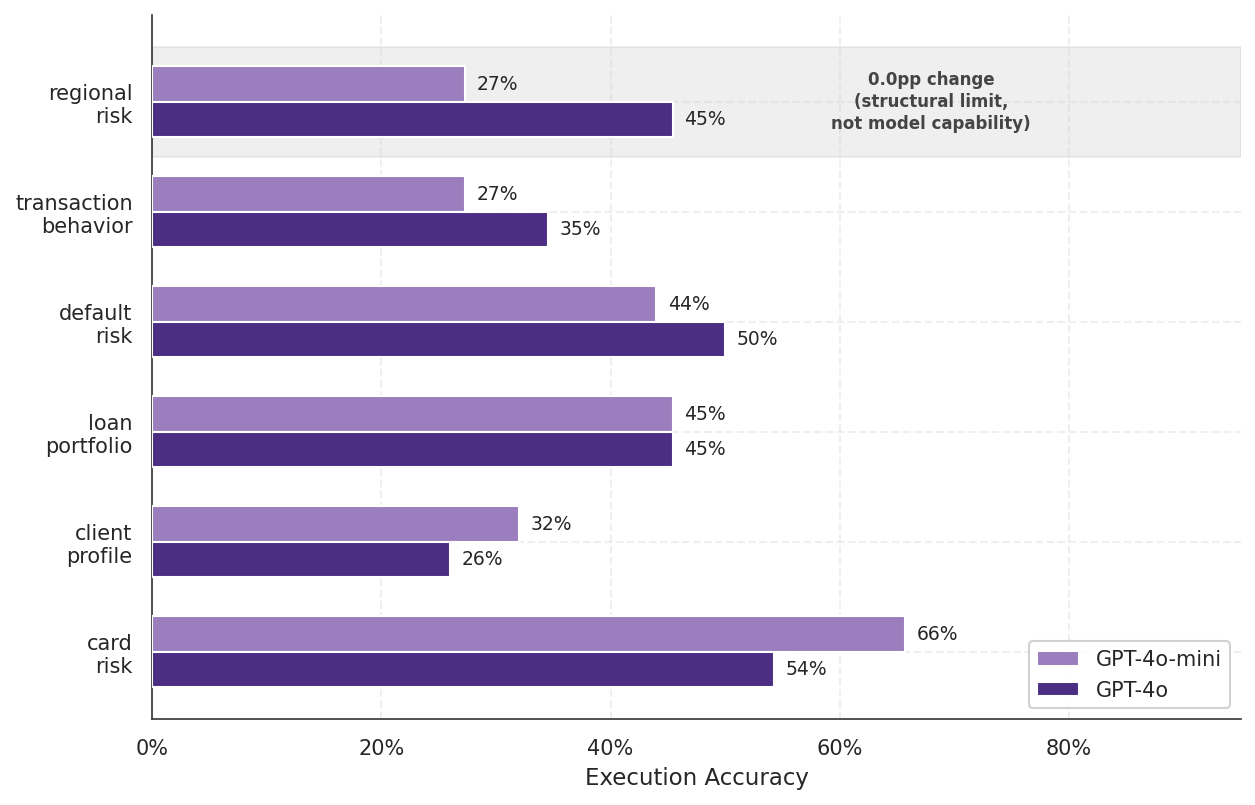

Saved: fig08_model_comparison.png  (316 KB, 600 DPI)

Verification: 12 data bars drawn (expected 12; 13 total patches including 1 highlight span).
✓ OK
Figures present in this directory:
  fig01_architecture_comparison.png  (695 KB)
  fig03_overall_accuracy.png  (292 KB)
  fig04_difficulty_accuracy.png  (375 KB)
  fig05_category_accuracy.png  (354 KB)
  fig06_exposure_comparison.png  (509 KB)
  fig07_iteration_stability.png  (280 KB)
  fig08_model_comparison.png  (316 KB)

✓ All 7 figures generated successfully.


In [1]:
# %% [markdown]
# # all_figures.ipynb
# Generates all 6 revised paper figures in one notebook. Run the
# style-setup cell first (Section 0); each figure section afterward
# is otherwise independent and can be re-run individually.
#
# Figures 1, 3, 4, 5, 6 use hardcoded, confirmed-final values (from
# 05a_exposure_final_check.py and 06_statistical_reanalysis.py's
# outputs) and require no data files to run.
#
# Figure 7 requires results_phase3_v2.csv and results_phase3_v2_arch.csv
# to be present in this directory (per-iteration data cannot be
# hardcoded meaningfully the way summary statistics can).

# %% [markdown]
# ## 0. Style setup (run this first -- all figure sections depend on it)

# %%
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

# ------------------------------------------------------------
# Seaborn theme -- clean, minimal-grid look (despined axes, dashed
# gridlines, no top/right spines).
# ------------------------------------------------------------
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.linewidth": 0.8,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.edgecolor": "#333333",
        "figure.dpi": 150,  # preview DPI; saved files use DPI_SAVE below
    }
)

# ------------------------------------------------------------
# Color palette. Same hex values as the pre-revision figures for
# visual continuity, plus a third color (C_SL_V1) for the
# non-encapsulating Semantic Layer implementation now shown
# explicitly alongside v2.
# ------------------------------------------------------------
C_SQL   = '#C94F2C'   # Text-to-SQL         — red-orange
C_SL_V1 = '#7AAFD4'   # Semantic Layer v1   — light blue (non-encapsulating)
C_SL_V2 = '#2C6FAC'   # Semantic Layer v2   — full blue (true info-hiding)
C_SQL_L = '#E8967A'   # light red-orange (secondary use)

DPI_SAVE = 600


def finalize_and_save(fig, path, dpi=DPI_SAVE):
    """Common save path: tight layout, save, report size."""
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.show()
    size_kb = os.path.getsize(path) / 1024
    print(f"Saved: {path}  ({size_kb:.0f} KB, {dpi} DPI)")


print("Style setup complete. C_SQL, C_SL_V1, C_SL_V2, DPI_SAVE, and")
print("finalize_and_save() are now available to every section below.")


# %% [markdown]
# ## Figure 1 — Architecture Comparison (Text-to-SQL / SL v1 / SL v2)
#
# Replaces the original Figure 1. The original was a two-column flow
# diagram (Text-to-SQL -> 15 columns exposed; Semantic Layer -> 0
# exposed). This is now three columns, since v1 -- the architecture
# originally shown achieving 0 exposure -- was found under exhaustive
# verification to expose all 15 columns via its concept-to-SQL
# mapping table included in the prompt. The distinction the figure
# must convey is WHERE the concept-to-column mapping is resolved: v1
# resolves it inside the prompt; v2 resolves it in a local compiler
# after the LLM responds.

# %%
sns.set_theme(style="white")  # this diagram has no axes/gridlines

fig, axes = plt.subplots(1, 3, figsize=(13, 7.5))

column_specs = [
    {
        'ax_idx': 0,
        'title': 'Text-to-SQL\n(baseline)',
        'boxes': [
            ('LLM', '#8B7FC7', 'white'),
            ('Raw DDL schema', C_SQL, 'white'),
            ('A2, A3 ... A16\nSensitive columns exposed', C_SQL, 'white'),
            ('Financial database', '#AAAAAA', 'black'),
        ],
        'result_text': '15 sensitive columns\nexposed to LLM',
        'result_color': C_SQL,
    },
    {
        'ax_idx': 1,
        'title': 'Semantic Layer v1\n(non-encapsulating --\nconfirmed NOT to hide schema)',
        'boxes': [
            ('LLM', '#8B7FC7', 'white'),
            ('Concept names +\nconcept-to-SQL mapping TABLE\n(included in prompt)', C_SL_V1, 'white'),
            ('A2, A3 ... A16\npresent in mapping table', C_SL_V1, 'white'),
            ('Financial database', '#AAAAAA', 'black'),
        ],
        'result_text': '15 sensitive columns\nexposed to LLM\n(0% reduction)',
        'result_color': C_SL_V1,
    },
    {
        'ax_idx': 2,
        'title': 'Semantic Layer v2\n(true information hiding --\nverified 0/15 exposure)',
        'boxes': [
            ('LLM', '#8B7FC7', 'white'),
            ('Concept names ONLY\n(no mapping in prompt)', C_SL_V2, 'white'),
            ('Local compiler\n(mapping applied AFTER\nLLM responds)', C_SL_V2, 'white'),
            ('Financial database', '#AAAAAA', 'black'),
        ],
        'result_text': '0 sensitive columns\nexposed to LLM\n(100% reduction)',
        'result_color': C_SL_V2,
    },
]

box_w, box_h = 0.72, 0.13
box_gap = 0.06
top_y = 0.90

for spec in column_specs:
    ax = axes[spec['ax_idx']]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(spec['title'], fontsize=11, fontweight='bold', pad=12)

    y = top_y
    box_centers = []
    for text, facecolor, textcolor in spec['boxes']:
        box = FancyBboxPatch(
            (0.14, y - box_h/2), box_w, box_h,
            boxstyle="round,pad=0.01,rounding_size=0.02",
            facecolor=facecolor, edgecolor='black', linewidth=0.8, zorder=3,
        )
        ax.add_patch(box)
        ax.text(0.5, y, text, ha='center', va='center', fontsize=8.5,
                color=textcolor, fontweight='medium', zorder=4, linespacing=1.3)
        box_centers.append(y)
        y -= (box_h + box_gap)

    for y_from, y_to in zip(box_centers[:-1], box_centers[1:]):
        ax.annotate('', xy=(0.5, y_to + box_h/2 + 0.01),
                    xytext=(0.5, y_from - box_h/2 - 0.01),
                    arrowprops=dict(arrowstyle='-|>', color='#555555', lw=1.3))

    result_y = box_centers[-1] - (box_h + box_gap)
    ax.annotate('', xy=(0.5, result_y + box_h/2 + 0.01),
                xytext=(0.5, box_centers[-1] - box_h/2 - 0.01),
                arrowprops=dict(arrowstyle='-|>', color='#555555', lw=1.3))
    result_box = FancyBboxPatch(
        (0.10, result_y - box_h*0.7), box_w + 0.08, box_h * 1.4,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        facecolor=spec['result_color'], edgecolor='black', linewidth=1.4, zorder=3,
    )
    ax.add_patch(result_box)
    ax.text(0.5, result_y, spec['result_text'], ha='center', va='center',
            fontsize=9.5, color='white', fontweight='bold', zorder=4, linespacing=1.3)

fig.text(0.635, 0.5, 'Information Hiding\n(Parnas, 1972)\napplied correctly →',
          ha='center', va='center', fontsize=8.5, style='italic', color='#333333',
          rotation=0, linespacing=1.4)

finalize_and_save(fig, 'fig01_architecture_comparison.png')

sns.set_theme(  # restore the whitegrid theme for the remaining figures
    style="whitegrid",
    rc={
        "font.family": "DejaVu Sans", "font.size": 11, "axes.titlesize": 12,
        "axes.labelsize": 11, "xtick.labelsize": 10, "ytick.labelsize": 10,
        "legend.fontsize": 10, "axes.linewidth": 0.8, "grid.alpha": 0.3,
        "grid.linestyle": "--", "axes.edgecolor": "#333333", "figure.dpi": 150,
    }
)


# %% [markdown]
# ## Figure 3 — Overall Accuracy Comparison (All Phases)
#
# Replaces the original Figure 1 (Overall Accuracy Comparison). Phase
# 3 now shows Text-to-SQL / SL v1 / SL v2 (three bars), with the
# significance annotation reflecting the QUESTION-LEVEL paired test
# between v1 and v2 (Reviewer 1 Concern #2). Phases 1 and 2 are
# unchanged (not part of this revision's re-analysis scope) and
# remain hardcoded; Phase 3's v1/v2 accuracy and p-value are computed
# DIRECTLY from results_phase3_v2.csv / results_phase3_v2_arch.csv
# below, rather than hardcoded, so this figure cannot silently drift
# out of sync with the actual data if those files are updated.

# %%
from scipy import stats as _scipy_stats

phases = ['Phase 1\n(ACME)', 'Phase 2\n(BIRD)', 'Phase 3\n(Credit Rating)']

# Phase 1/2: unchanged, hardcoded (outside this revision's scope)
phase1_sql, phase1_sl = 0.629, 0.754
phase2_sql, phase2_sl = 0.387, 0.425
# Phase 3 Text-to-SQL: unchanged from the original manuscript (not
# re-run in this revision; only v1/v2 were re-run)
phase3_sql = 0.390

if os.path.exists('results_phase3_v2.csv') and os.path.exists('results_phase3_v2_arch.csv'):
    _df_v1_fig3 = pd.read_csv('results_phase3_v2.csv')
    _df_v2_fig3 = pd.read_csv('results_phase3_v2_arch.csv')
    phase3_v1 = _df_v1_fig3['is_correct'].mean()
    phase3_v2 = _df_v2_fig3['is_correct'].mean()

    _q_v1_fig3 = _df_v1_fig3.groupby('question_id')['is_correct'].mean()
    _q_v2_fig3 = _df_v2_fig3.groupby('question_id')['is_correct'].mean()
    _common_fig3 = sorted(set(_q_v1_fig3.index) & set(_q_v2_fig3.index))
    _t_stat_fig3, _p_value_fig3 = _scipy_stats.ttest_rel(
        _q_v2_fig3.loc[_common_fig3].values, _q_v1_fig3.loc[_common_fig3].values
    )
    print(f"Figure 3: computed Phase 3 v1={phase3_v1:.1%}, v2={phase3_v2:.1%}, "
          f"paired p={_p_value_fig3:.4g} (n={len(_common_fig3)} question pairs)")
else:
    raise FileNotFoundError(
        "results_phase3_v2.csv and/or results_phase3_v2_arch.csv not found -- "
        "Figure 3 requires these to compute Phase 3's v1/v2 accuracy and "
        "significance directly rather than using a stale hardcoded snapshot. "
        "Place both files in this directory before running this section."
    )

data = pd.DataFrame({
    'phase': ['Phase 1\n(ACME)', 'Phase 1\n(ACME)',
              'Phase 2\n(BIRD)', 'Phase 2\n(BIRD)',
              'Phase 3\n(Credit Rating)', 'Phase 3\n(Credit Rating)', 'Phase 3\n(Credit Rating)'],
    'condition': ['Text-to-SQL', 'SL v2',
                  'Text-to-SQL', 'SL v2',
                  'Text-to-SQL', 'SL v1', 'SL v2'],
    'accuracy': [phase1_sql, phase1_sl,
                 phase2_sql, phase2_sl,
                 phase3_sql, phase3_v1, phase3_v2],
})

fig, ax = plt.subplots(figsize=(9.5, 6))

phase_x = {phases[0]: 0, phases[1]: 1.3, phases[2]: 2.9}
bar_w = 0.28

for phase in [phases[0], phases[1]]:
    sub = data[data['phase'] == phase]
    x0 = phase_x[phase]
    for i, (_, row) in enumerate(sub.iterrows()):
        offset = (-0.5 + i) * bar_w
        color = C_SQL if row['condition'] == 'Text-to-SQL' else C_SL_V2
        bar = ax.bar(x0 + offset, row['accuracy'], bar_w,
                      color=color, zorder=3, label=row['condition'])
        ax.text(x0 + offset, row['accuracy'] + 0.012, f"{row['accuracy']:.1%}",
                ha='center', va='bottom', fontsize=9.5, fontweight='bold')

sub = data[data['phase'] == phases[2]]
x0 = phase_x[phases[2]]
colors_p3 = {'Text-to-SQL': C_SQL, 'SL v1': C_SL_V1, 'SL v2': C_SL_V2}
offsets_p3 = {'Text-to-SQL': -bar_w * 1.05, 'SL v1': 0, 'SL v2': bar_w * 1.05}
bar_positions_p3 = {}
for _, row in sub.iterrows():
    offset = offsets_p3[row['condition']]
    bar_positions_p3[row['condition']] = x0 + offset
    color = colors_p3[row['condition']]
    bar = ax.bar(x0 + offset, row['accuracy'], bar_w,
                  color=color, zorder=3, label=row['condition'])
    ax.text(x0 + offset, row['accuracy'] + 0.012, f"{row['accuracy']:.1%}",
            ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.annotate('', xy=(phase_x[phases[0]] + bar_w/2, phase1_sl + 0.05),
            xytext=(phase_x[phases[0]] - bar_w/2, phase1_sl + 0.05),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))
ax.text(phase_x[phases[0]], phase1_sl + 0.065, '***', ha='center', fontsize=11)

top2 = max(phase2_sql, phase2_sl) + 0.045
ax.annotate('', xy=(phase_x[phases[1]] + bar_w/2, top2),
            xytext=(phase_x[phases[1]] - bar_w/2, top2),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))
ax.text(phase_x[phases[1]], top2 + 0.012, 'n.s.', ha='center', fontsize=9)

top3 = max(phase3_v1, phase3_v2) + 0.06
ax.annotate('', xy=(bar_positions_p3['SL v2'], top3),
            xytext=(bar_positions_p3['SL v1'], top3),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))
p_label = f'p = {_p_value_fig3:.3f}' if _p_value_fig3 >= 0.001 else 'p < 0.001'
sig_label = '(n.s.)' if _p_value_fig3 >= 0.05 else '(significant)'
ax.text((bar_positions_p3['SL v1'] + bar_positions_p3['SL v2']) / 2, top3 + 0.012,
        f'{p_label} {sig_label}\nquestion-level paired test',
        ha='center', fontsize=8, linespacing=1.4)

ax.set_xticks([phase_x[p] for p in phases])
ax.set_xticklabels(phases)
ax.set_xlim(-0.6, 3.5)
ax.set_ylabel('Execution Accuracy')
ax.set_ylim(0, 0.95)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
legend_order = ['Text-to-SQL', 'SL v1', 'SL v2']
ordered_handles = [seen[l] for l in legend_order if l in seen]
ax.legend(ordered_handles, [l for l in legend_order if l in seen],
          loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, framealpha=0.9)

sns.despine(ax=ax)
finalize_and_save(fig, 'fig03_overall_accuracy.png')


# %% [markdown]
# ## Figure 4 — Accuracy by Difficulty Level (Jagged Frontier)
#
# Replaces the original Figure 2. Phase 2 (BIRD) panel unchanged
# (hardcoded, outside this revision's re-analysis scope). Phase 3
# panel is computed DIRECTLY from results_phase3_v2.csv /
# results_phase3_v2_arch.csv (reusing the same files Figure 3 loads,
# so both figures always show mutually consistent numbers), rather
# than a hardcoded snapshot.

# %%
diffs = ['Simple', 'Moderate', 'Challenging']

phase2_sl  = [0.548, 0.297, 0.000]
phase2_sql = [0.532, 0.216, 0.000]

if os.path.exists('results_phase3_v2.csv') and os.path.exists('results_phase3_v2_arch.csv'):
    _df_v1_fig4 = pd.read_csv('results_phase3_v2.csv')
    _df_v2_fig4 = pd.read_csv('results_phase3_v2_arch.csv')

    _diff_order = ['simple', 'moderate', 'challenging']
    _by_diff_v1 = _df_v1_fig4.groupby('difficulty')['is_correct'].mean().reindex(_diff_order)
    _by_diff_v2 = _df_v2_fig4.groupby('difficulty')['is_correct'].mean().reindex(_diff_order)

    if _by_diff_v1.isna().any() or _by_diff_v2.isna().any():
        raise ValueError(
            f"One or more difficulty labels in {_diff_order} not found in the "
            f"results files -- check the 'difficulty' column's actual values "
            f"(found: v1={sorted(_df_v1_fig4['difficulty'].unique())}, "
            f"v2={sorted(_df_v2_fig4['difficulty'].unique())})."
        )

    phase3_v1 = _by_diff_v1.tolist()
    phase3_v2 = _by_diff_v2.tolist()
    print(f"Figure 4: computed Phase 3 v1={[f'{x:.1%}' for x in phase3_v1]}, "
          f"v2={[f'{x:.1%}' for x in phase3_v2]}")
else:
    raise FileNotFoundError(
        "results_phase3_v2.csv and/or results_phase3_v2_arch.csv not found -- "
        "Figure 4 requires these to compute Phase 3's difficulty-level accuracy "
        "directly. Place both files in this directory before running this section."
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
x = np.arange(len(diffs))
w = 0.32

ax = axes[0]
b_sl  = ax.bar(x - w/2, phase2_sl,  w, label='Semantic Layer', color=C_SL_V2, zorder=3)
b_sql = ax.bar(x + w/2, phase2_sql, w, label='Text-to-SQL',    color=C_SQL,   zorder=3)
for bar in list(b_sl) + list(b_sql):
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(diffs)
ax.set_title('Phase 2 (BIRD Financial)')
ax.set_xlabel('Difficulty Level')
ax.set_ylabel('Execution Accuracy')
ax.legend(loc='upper right', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
sns.despine(ax=ax)

ax = axes[1]
b_v1 = ax.bar(x - w/2, phase3_v1, w, label='SL v1', color=C_SL_V1, zorder=3)
b_v2 = ax.bar(x + w/2, phase3_v2, w, label='SL v2', color=C_SL_V2, zorder=3)
for bar in list(b_v1) + list(b_v2):
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(diffs)
ax.set_title('Phase 3 (Credit Rating)')
ax.set_xlabel('Difficulty Level')
ax.legend(loc='upper right', framealpha=0.9)
sns.despine(ax=ax)

axes[0].set_ylim(0, 0.90)
finalize_and_save(fig, 'fig04_difficulty_accuracy.png')

n_bars = sum(len(ax.patches) for ax in axes)
print(f"Verification: {n_bars} bar patches drawn (expected 12).")
assert n_bars == 12, f"Unexpected bar count: {n_bars}"
print("✓ OK")


# %% [markdown]
# ## Figure 5 — Accuracy by Category (Phase 3, v1 vs v2)
#
# Replaces the original Figure 3/5. The story has changed: v2 now
# outperforms v1 in default_risk (+12.0pp) and loan_portfolio
# (+0.9pp), and underperforms most in regional_risk (-20.0pp) and
# transaction_behavior (-13.6pp), driven by identifiable failure
# patterns (multi-hop join compression; date-literal and
# composite-ratio measure limitations -- see Section 5.4).

# %%
category_data = pd.DataFrame({
    'category': ['card_risk', 'client_profile', 'default_risk',
                 'loan_portfolio', 'regional_risk', 'transaction_behavior'],
    'v1': [0.4857, 0.3400, 0.3000, 0.4273, 0.4000, 0.3909],
    'v2': [0.4286, 0.2800, 0.4200, 0.4364, 0.2000, 0.2545],
})
category_data['diff'] = category_data['v2'] - category_data['v1']
category_data = category_data.sort_values('diff', ascending=True).reset_index(drop=True)
category_data['category_label'] = category_data['category'].str.replace('_', '\n')

fig, ax = plt.subplots(figsize=(8.5, 5.5))
y = np.arange(len(category_data))
h = 0.32

b_v1 = ax.barh(y + h/2, category_data['v1'], h, label='SL v1', color=C_SL_V1, zorder=3)
b_v2 = ax.barh(y - h/2, category_data['v2'], h, label='SL v2', color=C_SL_V2, zorder=3)

for bar in list(b_v1) + list(b_v2):
    if bar.get_width() > 0.01:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.0%}', ha='left', va='center', fontsize=9)

for cat_name, note in [('regional_risk', '-20.0pp\n(multi-hop join\nfailures)'),
                         ('transaction_behavior', '-13.6pp\n(date/measure\nlimitations)')]:
    idx = list(category_data['category']).index(cat_name)
    ax.axhspan(idx - 0.5, idx + 0.5, alpha=0.08, color=C_SL_V1, zorder=0)
    ax.text(0.62, idx, note, ha='center', va='center', fontsize=8,
            color=C_SL_V1, fontweight='bold', linespacing=1.3)

idx = list(category_data['category']).index('default_risk')
ax.axhspan(idx - 0.5, idx + 0.5, alpha=0.08, color=C_SL_V2, zorder=0)
ax.text(0.62, idx, '+12.0pp\n(v2 advantage)', ha='center', va='center', fontsize=8,
        color=C_SL_V2, fontweight='bold', linespacing=1.3)

ax.set_yticks(y)
ax.set_yticklabels(category_data['category_label'])
ax.set_xlabel('Execution Accuracy')
ax.set_xlim(0, 0.85)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='lower right', framealpha=0.9)
sns.despine(ax=ax)

finalize_and_save(fig, 'fig05_category_accuracy.png')


# %% [markdown]
# ## Figure 6 — Sensitive Information Exposure (RQ2)
#
# Replaces the original Figure 4/6. Now a THREE-WAY comparison
# (Text-to-SQL / SL v1 / SL v2) instead of two-way, since v1 exposes
# all 15 columns identically to Text-to-SQL.

# %%
SENSITIVE_COLS = [f"A{i}" for i in range(2, 17)]

exposure_by_column = pd.DataFrame({
    'column': SENSITIVE_COLS,
    'Text-to-SQL': [1] * 15,
    'SL v1': [1] * 15,
    'SL v2': [0] * 15,
})

summary_metrics = ['Sensitive Columns\nExposed (of 15)', 'Internal Codes\nExposed (of 9)']
summary_data = pd.DataFrame({
    'metric': summary_metrics * 3,
    'condition': ['Text-to-SQL']*2 + ['SL v1']*2 + ['SL v2']*2,
    'count': [15, 0, 15, 0, 0, 0],
})

palette = {'Text-to-SQL': C_SQL, 'SL v1': C_SL_V1, 'SL v2': C_SL_V2}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.5))

melted = exposure_by_column.melt(id_vars='column', var_name='condition', value_name='exposed')
melted['column'] = pd.Categorical(melted['column'], categories=SENSITIVE_COLS[::-1], ordered=True)

sns.barplot(
    data=melted, y='column', x='exposed', hue='condition',
    palette=palette, ax=ax1, orient='h', order=SENSITIVE_COLS[::-1],
    hue_order=['Text-to-SQL', 'SL v1', 'SL v2'],
)
ax1.set_xlabel('Exposed in LLM Prompt\n(1 = exposed, 0 = hidden)')
ax1.set_ylabel('')
ax1.set_xlim(-0.1, 1.1)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Hidden (0)', 'Exposed (1)'])
ax1.set_title('(a) Sensitive Column Exposure\n(Schema-level, per column)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, framealpha=0.9, title=None)
sns.despine(ax=ax1)

sns.barplot(
    data=summary_data, x='metric', y='count', hue='condition',
    palette=palette, ax=ax2, hue_order=['Text-to-SQL', 'SL v1', 'SL v2'],
)
for container in ax2.containers:
    ax2.bar_label(container, fontsize=10, fontweight='bold', padding=2)

ax2.set_xlabel('')
ax2.set_ylabel('Number of Exposed Items')
ax2.set_ylim(0, 20)
ax2.set_title('(b) Exposure Summary\n(Schema-level)')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, framealpha=0.9, title=None)
sns.despine(ax=ax2)

ax2.annotate('v1: 0% reduction\n(15 -> 15)', xy=(-0.13, 15), xytext=(0.35, 17.5),
             arrowprops=dict(arrowstyle='->', color=C_SL_V1, lw=1.5),
             fontsize=9, color=C_SL_V1, fontweight='bold', ha='center')
ax2.annotate('v2: 100% reduction\n(15 -> 0)', xy=(0.13, 0.3), xytext=(0.55, 6),
             arrowprops=dict(arrowstyle='->', color=C_SL_V2, lw=1.5),
             fontsize=9, color=C_SL_V2, fontweight='bold', ha='center')

finalize_and_save(fig, 'fig06_exposure_comparison.png')


# %% [markdown]
# ## Figure 7 — Iteration Stability (Phase 3, v1 vs v2)
#
# Replaces the original Figure 5/7. Requires results_phase3_v2.csv
# (v1) and results_phase3_v2_arch.csv (v2) in this directory --
# per-iteration data cannot be hardcoded the way summary statistics
# can, so this section will raise a clear error rather than silently
# approximating a curve if those files are missing.

# %%
if os.path.exists('results_phase3_v2.csv') and os.path.exists('results_phase3_v2_arch.csv'):
    df_v1 = pd.read_csv('results_phase3_v2.csv')
    df_v2 = pd.read_csv('results_phase3_v2_arch.csv')
    by_iter_v1 = df_v1.groupby('iteration')['is_correct'].mean()
    by_iter_v2 = df_v2.groupby('iteration')['is_correct'].mean()
    print("Loaded actual per-iteration data from results files.")
    print(f"v1 per-iteration: {by_iter_v1.values}")
    print(f"v2 per-iteration: {by_iter_v2.values}")

    fig, ax = plt.subplots(figsize=(8, 5))
    iterations = by_iter_v2.index.values + 1

    ax.plot(iterations, by_iter_v2.values, marker='o', markersize=7, linewidth=1.8,
            label='SL v2', color=C_SL_V2, zorder=3)
    ax.plot(iterations, by_iter_v1.values, marker='s', markersize=7, linewidth=1.8,
            label='SL v1', color=C_SL_V1, zorder=3)

    sl_v2_mean, sl_v2_std = by_iter_v2.mean(), by_iter_v2.std()
    sl_v1_mean, sl_v1_std = by_iter_v1.mean(), by_iter_v1.std()

    ax.axhline(sl_v2_mean, color=C_SL_V2, linestyle='--', linewidth=0.9, alpha=0.6)
    ax.axhline(sl_v1_mean, color=C_SL_V1, linestyle='--', linewidth=0.9, alpha=0.6)

    x_max = iterations.max()
    ax.text(x_max + 0.1, sl_v2_mean, f'σ={sl_v2_std:.3f}', color=C_SL_V2, fontsize=9, va='center')
    ax.text(x_max + 0.1, sl_v1_mean, f'σ={sl_v1_std:.3f}', color=C_SL_V1, fontsize=9, va='center')

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Execution Accuracy')
    ax.set_xticks(iterations)
    y_min = min(by_iter_v1.min(), by_iter_v2.min()) - 0.08
    y_max = max(by_iter_v1.max(), by_iter_v2.max()) + 0.08
    ax.set_ylim(max(0, y_min), y_max)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(loc='upper right', framealpha=0.9)
    sns.despine(ax=ax)

    finalize_and_save(fig, 'fig07_iteration_stability.png')

    print(f"\nv2 mean across iterations: {sl_v2_mean:.4f} (should match overall v2 accuracy 0.330 closely)")
    print(f"v1 mean across iterations: {sl_v1_mean:.4f} (should match overall v1 accuracy 0.387 closely)")
else:
    print("!! results_phase3_v2.csv and/or results_phase3_v2_arch.csv not found")
    print("   in the current directory. Place both files here and re-run this")
    print("   section to generate fig07_iteration_stability.png -- skipping")
    print("   rather than approximating the curve from summary statistics.")


# %% [markdown]
# ## Figure 8 — Model Comparison (GPT-4o-mini vs GPT-4o, v2 architecture)
#
# NEW figure supporting Section 5.5 (Reviewer 2 Concern #2). Same
# format as Figure 5, but compares the two MODELS on the v2
# architecture rather than the two ARCHITECTURES on one model. Uses
# a distinct color pair (C_MODEL_MINI / C_MODEL_4O) so it's visually
# distinguishable from Figure 5's v1/v2 comparison at a glance, even
# though both are horizontal grouped-bar category charts.
#
# Requires results_phase3_v2_arch.csv (GPT-4o-mini) and
# results_phase3_v2_gpt4o.csv (GPT-4o) in this directory.

# %%
C_MODEL_MINI = '#9B7EBD'   # GPT-4o-mini — muted purple (distinct from the v1/v2 blue pair)
C_MODEL_4O   = '#4B2E83'   # GPT-4o      — deep purple

if os.path.exists('results_phase3_v2_arch.csv') and os.path.exists('results_phase3_v2_gpt4o.csv'):
    df_mini_fig8 = pd.read_csv('results_phase3_v2_arch.csv')
    df_4o_fig8 = pd.read_csv('results_phase3_v2_gpt4o.csv')

    cat_mini_fig8 = df_mini_fig8.groupby('category')['is_correct'].mean()
    cat_4o_fig8 = df_4o_fig8.groupby('category')['is_correct'].mean()

    model_category_data = pd.DataFrame({
        'category': cat_mini_fig8.index,
        'GPT-4o-mini': cat_mini_fig8.values,
        'GPT-4o': cat_4o_fig8.reindex(cat_mini_fig8.index).values,
    })
    model_category_data['diff'] = model_category_data['GPT-4o'] - model_category_data['GPT-4o-mini']
    model_category_data = model_category_data.sort_values('diff', ascending=True).reset_index(drop=True)
    model_category_data['category_label'] = model_category_data['category'].str.replace('_', '\n')

    print("Loaded category-level data for both models:")
    print(model_category_data[['category', 'GPT-4o-mini', 'GPT-4o', 'diff']])

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    y = np.arange(len(model_category_data))
    h = 0.32

    b_mini = ax.barh(y + h/2, model_category_data['GPT-4o-mini'], h,
                      label='GPT-4o-mini', color=C_MODEL_MINI, zorder=3)
    b_4o = ax.barh(y - h/2, model_category_data['GPT-4o'], h,
                   label='GPT-4o', color=C_MODEL_4O, zorder=3)

    for bar in list(b_mini) + list(b_4o):
        if bar.get_width() > 0.01:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{bar.get_width():.0%}', ha='left', va='center', fontsize=9)

    # Highlight the key finding from Section 5.5: regional_risk shows
    # ZERO improvement despite the stronger model (structural
    # limitation, not a capability gap)
    if 'regional_risk' in model_category_data['category'].values:
        idx = list(model_category_data['category']).index('regional_risk')
        ax.axhspan(idx - 0.5, idx + 0.5, alpha=0.10, color='#666666', zorder=0)
        ax.text(0.68, idx, '0.0pp change\n(structural limit,\nnot model capability)',
                ha='center', va='center', fontsize=8, color='#444444',
                fontweight='bold', linespacing=1.3)

    ax.set_yticks(y)
    ax.set_yticklabels(model_category_data['category_label'])
    ax.set_xlabel('Execution Accuracy')
    ax.set_xlim(0, 0.95)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(loc='lower right', framealpha=0.9)
    sns.despine(ax=ax)

    finalize_and_save(fig, 'fig08_model_comparison.png')

    # NOTE: ax.patches includes BOTH the data bars (from barh) AND the
    # axhspan() highlight rectangle drawn above for regional_risk (if
    # present) -- axhspan also creates a Rectangle patch. Subtract the
    # known number of axhspan calls (0 or 1, depending on whether
    # regional_risk is in this data) before checking the bar count,
    # rather than asserting on the raw patch count directly.
    n_axhspan_calls = 1 if 'regional_risk' in model_category_data['category'].values else 0
    n_bars_fig8 = len(ax.patches) - n_axhspan_calls
    print(f"\nVerification: {n_bars_fig8} data bars drawn "
          f"(expected {2 * len(model_category_data)}; "
          f"{len(ax.patches)} total patches including "
          f"{n_axhspan_calls} highlight span).")
    assert n_bars_fig8 == 2 * len(model_category_data), f"Unexpected bar count: {n_bars_fig8}"
    print("✓ OK")
else:
    print("!! results_phase3_v2_arch.csv and/or results_phase3_v2_gpt4o.csv not")
    print("   found in the current directory. Place both files here and re-run")
    print("   this section to generate fig08_model_comparison.png -- skipping")
    print("   rather than fabricating category-level data that can only come")
    print("   from the actual GPT-4o experiment run.")


# %% [markdown]
# ## All figures generated

# %%
figures = [f for f in os.listdir('.') if f.startswith('fig0') and f.endswith('.png')]
print("Figures present in this directory:")
for f in sorted(figures):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f}  ({size_kb:.0f} KB)")

expected = {'fig01_architecture_comparison.png', 'fig03_overall_accuracy.png',
            'fig04_difficulty_accuracy.png', 'fig05_category_accuracy.png',
            'fig06_exposure_comparison.png', 'fig07_iteration_stability.png',
            'fig08_model_comparison.png'}
missing = expected - set(figures)
if missing:
    print(f"\nNot yet generated: {missing}")
    data_dependent = {'fig07_iteration_stability.png', 'fig08_model_comparison.png'}
    if missing <= data_dependent:
        print("(expected if the underlying results CSVs weren't present when")
        print(" this notebook ran -- add them and re-run the relevant section(s)")
        print(" above: Figure 7 needs results_phase3_v2.csv +")
        print(" results_phase3_v2_arch.csv; Figure 8 needs")
        print(" results_phase3_v2_arch.csv + results_phase3_v2_gpt4o.csv.)")
else:
    print("\n✓ All 7 figures generated successfully.")